# Pipeline GreenDC — 2023 (Debug & Validation)

Même structure que `pipeline_v2.ipynb` (2022), adapté pour 2023.
Objectif : identifier et corriger les écarts qui causent 0/3 en validation.

## Problèmes identifiés
1. Eco2mix 2023 = 15min, lignes :15/:45 vides → fix: drop avant resample
2. `normalize_technology` fallback "other" → colonnes non-prod dispatchées
3. Transfos + FR137 corrections absentes du pipeline
4. Consommation calculée vs eco2mix réelle
5. STEP non séparé (turbinage/pompage)

In [1]:
import sys
sys.path.insert(0, '/home/alexis/Greendc')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('/home/alexis/Greendc')
RAW = ROOT / 'carbon_model' / 'data' / 'raw'
PROCESSED = ROOT / 'carbon_model' / 'data' / 'processed'
OUTPUTS = ROOT / 'carbon_model' / 'data' / 'outputs'

print(f'RAW exists: {RAW.exists()}')
print(f'eco2mix: {list((RAW / "rte").glob("eco2mix_*"))}')

YEAR = 2023

RAW exists: True
eco2mix: [PosixPath('/home/alexis/Greendc/carbon_model/data/raw/rte/eco2mix_2022..xls'), PosixPath('/home/alexis/Greendc/carbon_model/data/raw/rte/eco2mix_2022..xls:Zone.Identifier'), PosixPath('/home/alexis/Greendc/carbon_model/data/raw/rte/eco2mix_2023.csv'), PosixPath('/home/alexis/Greendc/carbon_model/data/raw/rte/eco2mix_2024.xls')]


---
## Étape 1 : Audit données brutes eco2mix 2023

In [2]:
# ── 1.1 Chargement eco2mix 2023 avec fix lignes vides ──
from carbon_model.downloaders.download_rte import RTEDownloader

loader = RTEDownloader(dest_dir=RAW / 'rte')

# Charger les deux années pour comparaison
rte_2023_path = sorted((RAW / 'rte').glob('eco2mix_2023*'))[0]
rte_2022_path = sorted((RAW / 'rte').glob('eco2mix_2022*'))[0]

rte_raw = loader.load_eco2mix_csv(rte_2023_path)
rte_22 = loader.load_eco2mix_csv(rte_2022_path)

print(f'2023 brut : {len(rte_raw)} timestamps × {rte_raw.shape[1]} colonnes')
print(f'2022 brut : {len(rte_22)} timestamps × {rte_22.shape[1]} colonnes')
print(f'2023 freq : {pd.infer_freq(rte_raw.index[:100])}')
print(f'2022 freq : {pd.infer_freq(rte_22.index[:100])}')
print(f'\nColonnes 2023 : {list(rte_raw.columns)}')

2026-03-21 20:50:21.123 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:309 - Eco2mix tab terminal détecté : header=40 cols, data=41 cols → correction
2026-03-21 20:50:21.472 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:439 - Eco2mix : 17520/35040 lignes vides supprimées (données 2023-01-01 00:00:00 → 2023-12-31 23:45:00, résolution < horaire)
2026-03-21 20:50:21.473 | SUCCESS  | carbon_model.downloaders.download_rte:load_eco2mix_csv:448 - Eco2mix chargé : 17520 timesteps
2026-03-21 20:50:21.474 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:309 - Eco2mix tab terminal détecté : header=40 cols, data=41 cols → correction
2026-03-21 20:50:21.795 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:439 - Eco2mix : 17520/35040 lignes vides supprimées (données 2022-01-01 00:00:00 → 2022-12-31 23:45:00, résolution < horaire)
2026-03-21 20:50:21.796 | SUCCESS  | carbon_model.downloaders.download_rte:load_eco2mix_csv

2023 brut : 17520 timestamps × 17 colonnes
2022 brut : 17520 timestamps × 17 colonnes
2023 freq : 30min
2022 freq : 30min

Colonnes 2023 : ['Nuclear', 'Wind Onshore', 'Solar', 'Hydro Run-of-river', 'Biomass', 'Fossil Gas', 'Fossil Oil', 'Fossil Hard Coal', 'Hydro Pumped Storage', 'consumption_mw', 'net_exchanges_mw', 'co2_rate_gco2_kwh', 'exchange_GB_mw', 'exchange_ES_mw', 'exchange_IT_mw', 'exchange_CH_mw', 'exchange_DEBE_mw']


In [3]:
# ── 1.2 Resample horaire et comparaison 2022 vs 2023 ──
rte_h = rte_raw.select_dtypes(include='number').resample('h').mean().fillna(0)
rte_h22 = rte_22.select_dtypes(include='number').resample('h').mean().fillna(0)

print(f'2023 horaire : {len(rte_h)} timestamps')
print(f'2022 horaire : {len(rte_h22)} timestamps')

# Colonnes de production
exclude_cols = {'consumption_mw', 'net_exchanges_mw', 'co2_rate_gco2_kwh'}
prod_cols = [c for c in rte_h.columns if c not in exclude_cols
             and not c.startswith('exchange_')]

print('\n── Production moyenne par filière (MW) ──')
print(f'{"Filière":30s} {"2023":>10s} {"2022":>10s} {"Ratio":>8s}')
print('-' * 62)
for c in prod_cols:
    v23 = rte_h[c].mean() if c in rte_h.columns else 0
    v22 = rte_h22[c].mean() if c in rte_h22.columns else 0
    ratio = v23 / v22 if v22 != 0 else float('nan')
    print(f'{c:30s} {v23:>10.0f} {v22:>10.0f} {ratio:>8.2f}')

# Consommation
print(f'\nConsommation 2023 : {rte_h["consumption_mw"].mean():.0f} MW')
print(f'Consommation 2022 : {rte_h22["consumption_mw"].mean():.0f} MW')

# CI RTE
if 'co2_rate_gco2_kwh' in rte_h.columns:
    ci_rte = rte_h['co2_rate_gco2_kwh']
    ci_rte_22 = rte_h22['co2_rate_gco2_kwh'] if 'co2_rate_gco2_kwh' in rte_h22.columns else None
    print(f'\nCI RTE 2023 : {ci_rte.mean():.1f} gCO2/kWh')
    if ci_rte_22 is not None:
        print(f'CI RTE 2022 : {ci_rte_22.mean():.1f} gCO2/kWh')

2023 horaire : 8760 timestamps
2022 horaire : 8760 timestamps

── Production moyenne par filière (MW) ──
Filière                              2023       2022    Ratio
--------------------------------------------------------------
Nuclear                             36552      31827     1.15
Wind Onshore                         5807       4438     1.31
Solar                                2535       2159     1.17
Hydro Run-of-river                   6633       5611     1.18
Biomass                              1178       1206     0.98
Fossil Gas                           3322       5008     0.66
Fossil Oil                            109        130     0.84
Fossil Hard Coal                       94        327     0.29
Hydro Pumped Storage                 -653       -849     0.77

Consommation 2023 : 49723 MW
Consommation 2022 : 51483 MW

CI RTE 2023 : 29.7 gCO2/kWh
CI RTE 2022 : 50.5 gCO2/kWh


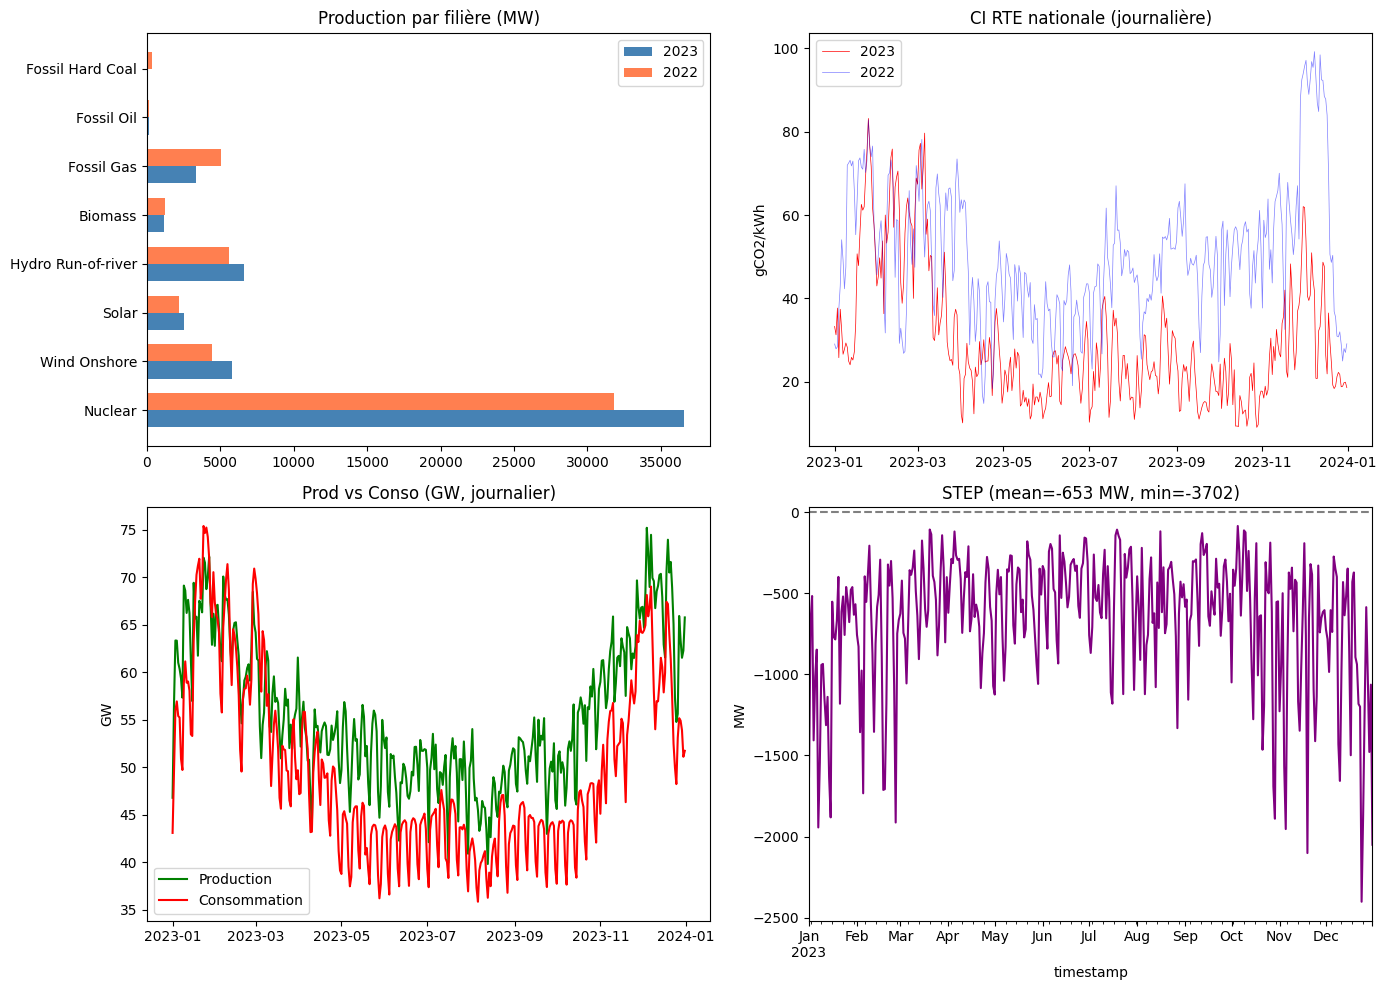

In [4]:
# ── 1.3 Visualisation comparative ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Production moyenne par filière
ax = axes[0, 0]
means_23 = {c: rte_h[c].mean() for c in prod_cols if rte_h[c].mean() > 0}
means_22 = {c: rte_h22[c].mean() for c in prod_cols if c in rte_h22.columns and rte_h22[c].mean() > 0}
x = range(len(means_23))
w = 0.35
ax.barh([i - w/2 for i in x], list(means_23.values()), w, label='2023', color='steelblue')
ax.barh([i + w/2 for i in x], [means_22.get(k, 0) for k in means_23.keys()], w, label='2022', color='coral')
ax.set_yticks(list(x)); ax.set_yticklabels(list(means_23.keys()))
ax.set_title('Production par filière (MW)'); ax.legend()

# 2. CI nationale journalière
ax = axes[0, 1]
if 'co2_rate_gco2_kwh' in rte_h.columns:
    ci_daily = rte_h['co2_rate_gco2_kwh'].resample('D').mean()
    ax.plot(ci_daily, linewidth=0.5, color='red', label='2023')
if 'co2_rate_gco2_kwh' in rte_h22.columns:
    ci_daily_22 = rte_h22['co2_rate_gco2_kwh'].resample('D').mean()
    ax.plot(ci_daily_22.index.map(lambda x: x.replace(year=2023)), ci_daily_22.values,
            linewidth=0.5, color='blue', alpha=0.5, label='2022')
ax.set_title('CI RTE nationale (journalière)'); ax.set_ylabel('gCO2/kWh'); ax.legend()

# 3. Bilan prod vs conso
ax = axes[1, 0]
total_prod = rte_h[prod_cols].sum(axis=1)
conso = rte_h['consumption_mw']
ax.plot(total_prod.resample('D').mean() / 1e3, label='Production', color='green')
ax.plot(conso.resample('D').mean() / 1e3, label='Consommation', color='red')
ax.set_title('Prod vs Conso (GW, journalier)'); ax.set_ylabel('GW'); ax.legend()

# 4. STEP
ax = axes[1, 1]
if 'Hydro Pumped Storage' in rte_h.columns:
    step = rte_h['Hydro Pumped Storage']
    step.resample('D').mean().plot(ax=ax, color='purple')
    ax.axhline(0, color='gray', linestyle='--')
    ax.set_title(f'STEP (mean={step.mean():.0f} MW, min={step.min():.0f})')
    ax.set_ylabel('MW')

plt.tight_layout(); plt.show()

---
## Étape 2–3 : Réseau + Centrales (identique 2022)

In [5]:
# ── 2-3 Construction réseau + centrales ──
import pypsa
from carbon_model.network.network_builder import build_network, network_to_geodataframes
from carbon_model.plants.plant_integrator import integrate_plants

# Charger réseau depuis cache
cached_nc = PROCESSED / 'network_france.nc'
net = pypsa.Network(str(cached_nc))
print(f'Réseau : {len(net.buses)} bus, {len(net.lines)} lignes')

# Intégrer centrales
plants_csv = RAW / 'plants' / 'plants_france_clean.csv'
buses_gdf, _ = network_to_geodataframes(net)
net, _ = integrate_plants(net, plants_csv, buses_gdf=buses_gdf)
print(f'Générateurs : {len(net.generators)}, capacité : {net.generators.p_nom.sum()/1e3:.1f} GW')

# Carriers disponibles
print('\n── Carriers ──')
for carrier, group in net.generators.groupby('carrier'):
    print(f'  {carrier:15s} : {len(group):>5d} gens, {group.p_nom.sum():>8.0f} MW')

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, lines


Réseau : 4393 bus, 5888 lignes


2026-03-21 20:50:27.962 | INFO     | carbon_model.network.network_builder:network_to_geodataframes:297 - GeoDataFrames : 4393 bus, 5888 lignes
2026-03-21 20:50:28.051 | INFO     | carbon_model.plants.plant_integrator:load_plants_registry:54 - Registre centrales : 46070 centrales, capacité totale 157.1 GW
tech_normalized
nuclear          62990.000000
hydro            25673.374350
wind             24029.882710
solar            20637.571718
gas              12748.640570
oil               2924.482400
biomass           2556.603699
wind_offshore     2008.200000
coal              1810.719000
storage           1458.254000
other              288.734000
geothermal           1.850000
2026-03-21 20:50:28.311 | INFO     | carbon_model.plants.plant_integrator:snap_plants_to_network:118 - Snapping centrales → réseau :
  Connectées   : 45937/46070 (100%)
  Capacité OK  : 156.3/157.1 GW
  Distance moy : 17.0 km
2026-03-21 20:50:28.314 | WARNING  | carbon_model.plants.plant_integrator:snap_plants_to_net

Générateurs : 3115, capacité : 156.3 GW

── Carriers ──
  biomass         :   442 gens,     2554 MW
  coal            :     6 gens,     1811 MW
  gas             :   364 gens,    12749 MW
  geothermal      :     1 gens,        2 MW
  hydro           :   443 gens,    25453 MW
  nuclear         :    18 gens,    62990 MW
  oil             :   119 gens,     2555 MW
  other           :    30 gens,      289 MW
  solar           :  1043 gens,    20466 MW
  storage         :   318 gens,     1453 MW
  wind            :   325 gens,    24012 MW
  wind_offshore   :     6 gens,     2008 MW


---
## Étape 4 : Dispatch (mapping explicite comme notebook v2)

In [6]:
# ── 4.1 Préparation production nationale avec mapping explicite ──
# Reproduit exactement le notebook pipeline_v2 cell [32]
from carbon_model.simulation.dispatch import (
    disaggregate_national_to_nodes, apply_dispatch_to_network,
    disaggregate_load_to_nodes
)

# Renommer Hydro comme dans le notebook v2
if 'Hydro Run-of-river' in rte_h.columns:
    rte_h.rename(columns={'Hydro Run-of-river': 'Hydro'}, inplace=True)
    print('✓ Hydro renommée')

# Mapping explicite colonnes eco2mix → carriers
carrier_col_map = {
    'Nuclear': 'nuclear',
    'Wind Onshore': 'wind',
    'Wind Offshore': 'wind_offshore',
    'Solar': 'solar',
    'Hydro': 'hydro',
    'Biomass': 'biomass',
    'Fossil Gas': 'gas',
    'Fossil Oil': 'oil',
    'Fossil Hard Coal': 'coal',
    'Hydro Pumped Storage': 'storage',
}

national_prod = pd.DataFrame(index=rte_h.index)
for eco_col, carrier in carrier_col_map.items():
    if eco_col in rte_h.columns:
        national_prod[carrier] = rte_h[eco_col].clip(lower=0).fillna(0)
    else:
        print(f'⚠ Colonne manquante : {eco_col}')

print(f'Production nationale : {national_prod.shape}')
print(f'Colonnes : {list(national_prod.columns)}')
print(f'Total moyen : {national_prod.sum(axis=1).mean()/1e3:.1f} GW')

# Dispatch capacity-weighted
dispatch_df = disaggregate_national_to_nodes(net, national_prod)
print(f'\nDispatch shape : {dispatch_df.shape}')

# Snapshots
snapshots = pd.date_range(f'{YEAR}-01-01', f'{YEAR}-12-31 23:00', freq='h')
apply_dispatch_to_network(net, dispatch_df, snapshots)

# Vérification conservation
disp_total = dispatch_df.sum(axis=1)
nat_total = national_prod.sum(axis=1)
ecart_pct = ((disp_total - nat_total).abs() / nat_total.replace(0, np.nan)).mean() * 100
print(f'Conservation dispatch : {ecart_pct:.4f}%')

2026-03-21 20:52:18.024 | INFO     | carbon_model.simulation.dispatch:disaggregate_national_to_nodes:44 - Désagrégation production nationale → nœuds (méthode: capacity_weighted)


✓ Hydro renommée
⚠ Colonne manquante : Wind Offshore
Production nationale : (8760, 9)
Colonnes : ['nuclear', 'wind', 'solar', 'hydro', 'biomass', 'gas', 'oil', 'coal', 'storage']
Total moyen : 56.2 GW


2026-03-21 20:52:18.494 | SUCCESS  | carbon_model.simulation.dispatch:disaggregate_national_to_nodes:86 - Dispatch vectorisé : 8760 timesteps × 3115 générateurs
2026-03-21 20:52:18.526 | INFO     | carbon_model.simulation.dispatch:apply_dispatch_to_network:114 - Dispatch appliqué :
  Production moyenne : 56.2 GW
  Production min     : 35.4 GW
  Production max     : 81.9 GW



Dispatch shape : (8760, 3115)
Conservation dispatch : 0.0000%


In [7]:
# ── 4.2 Consommation RTE réelle ──
national_conso = rte_h['consumption_mw'].fillna(0)
disaggregate_load_to_nodes(net, national_conso)
print(f'Loads créés : {len(net.loads)}')
print(f'Consommation moyenne : {national_conso.mean()/1e3:.1f} GW')

2026-03-21 20:52:43.515 | INFO     | carbon_model.simulation.dispatch:disaggregate_load_to_nodes:179 - Consommation ventilée sur 1210 nœuds :
  Consommation moyenne : 49.7 GW


Loads créés : 1210
Consommation moyenne : 49.7 GW


In [8]:
# ── 4.3 STEP : pompage → loads ──
step_col = [c for c in rte_h.columns if 'Pumped' in c or 'storage' in c.lower()]
print(f'Colonne STEP : {step_col}')

if len(step_col) > 0:
    step_national = rte_h[step_col[0]]
    print(f'STEP : min={step_national.min():.0f} MW, max={step_national.max():.0f} MW, mean={step_national.mean():.0f} MW')

    turbinage_national = step_national.clip(lower=0)
    pompage_national = step_national.clip(upper=0).abs()
    print(f'Turbinage moyen : {turbinage_national.mean():.0f} MW')
    print(f'Pompage moyen   : {pompage_national.mean():.0f} MW')

    # Redispatcher le turbinage sur les gens storage
    step_gens = net.generators[net.generators['carrier'] == 'storage'].index
    if len(step_gens) == 0:
        step_gens = net.generators[net.generators['carrier'] == 'hydro'].index
    step_caps = net.generators.loc[step_gens, 'p_nom']
    total_cap = step_caps.sum()
    print(f'\nGénérateurs storage : {len(step_gens)}, capacité : {total_cap:.0f} MW')

    weights = step_caps / total_cap
    for gen_id in step_gens:
        net.generators_t.p_set[gen_id] = turbinage_national * weights[gen_id]

    # Loads pompage
    for gen_id in step_gens:
        bus = net.generators.loc[gen_id, 'bus']
        load_id = f'load_step_{gen_id}'
        if load_id not in net.loads.index:
            net.add('Load', load_id, bus=bus)
        net.loads_t.p_set[load_id] = pompage_national * weights[gen_id]

    n_step_loads = sum(1 for idx in net.loads.index if idx.startswith('load_step_'))
    print(f'Loads STEP créés : {n_step_loads}')

Colonne STEP : ['Hydro Pumped Storage']
STEP : min=-3702 MW, max=-13 MW, mean=-653 MW
Turbinage moyen : 0 MW
Pompage moyen   : 653 MW

Générateurs storage : 318, capacité : 1453 MW
Loads STEP créés : 318


Production moyenne  : 56.2 GW
Consommation moyenne: 50.4 GW
Surplus (exports)   : 5.9 GW
Ratio prod/conso    : 1.116
Production TWh      : 492.6
Consommation TWh    : 441.3


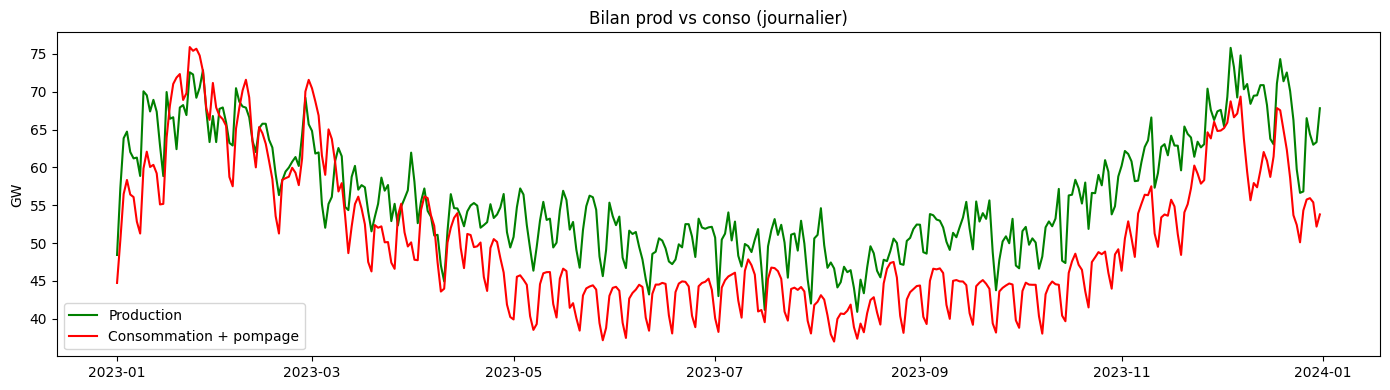

In [9]:
# ── 4.4 Bilan énergétique ──
prod_h = net.generators_t.p_set.sum(axis=1)
load_h = net.loads_t.p_set.sum(axis=1)

print(f'Production moyenne  : {prod_h.mean()/1e3:.1f} GW')
print(f'Consommation moyenne: {load_h.mean()/1e3:.1f} GW')
print(f'Surplus (exports)   : {(prod_h - load_h).mean()/1e3:.1f} GW')
print(f'Ratio prod/conso    : {prod_h.mean()/load_h.mean():.3f}')
print(f'Production TWh      : {prod_h.sum()/1e6:.1f}')
print(f'Consommation TWh    : {load_h.sum()/1e6:.1f}')

# Visualisation
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prod_h.resample('D').mean()/1e3, label='Production', color='green')
ax.plot(load_h.resample('D').mean()/1e3, label='Consommation + pompage', color='red')
ax.set_ylabel('GW'); ax.set_title('Bilan prod vs conso (journalier)'); ax.legend()
plt.tight_layout(); plt.show()

In [10]:
# ── 4.5 CI production directe (diagnostic, sans tracing) ──
from carbon_model.plants.emission_factors import EMISSION_FACTORS

ef_map = {'nuclear': 12, 'wind': 11, 'solar': 45, 'hydro': 24,
          'biomass': 230, 'gas': 410, 'oil': 650, 'coal': 820, 'storage': 5}

emissions_h = sum(national_prod[c] * ef_map.get(c, 0) for c in national_prod.columns)
production_h = national_prod.sum(axis=1)
ci_direct = emissions_h / production_h.replace(0, np.nan)

# Référence RTE
ci_rte = rte_h['co2_rate_gco2_kwh'] if 'co2_rate_gco2_kwh' in rte_h.columns else None

print('── CI PRODUCTION DIRECTE ──')
print(f'CI lifecycle moyen (nos EF) : {ci_direct.mean():.1f} gCO2/kWh')
if ci_rte is not None:
    print(f'CI RTE moyen (direct comb.) : {ci_rte.mean():.1f} gCO2/kWh')
    print(f'Ratio lifecycle/RTE         : {ci_direct.mean() / ci_rte.mean():.2f}')

# Décomposition
print('\n── Contributions CO2 par carrier ──')
for c in national_prod.columns:
    if c in ef_map:
        e = (national_prod[c] * ef_map[c]).sum()
        p = national_prod[c].sum()
        print(f'  {c:12s} : {p/1e6:.1f} TWh x {ef_map[c]:4d} EF = {e/1e9:.2f} MtCO2')

── CI PRODUCTION DIRECTE ──
CI lifecycle moyen (nos EF) : 44.5 gCO2/kWh
CI RTE moyen (direct comb.) : 29.7 gCO2/kWh
Ratio lifecycle/RTE         : 1.50

── Contributions CO2 par carrier ──
  nuclear      : 320.2 TWh x   12 EF = 3.84 MtCO2
  wind         : 50.9 TWh x   11 EF = 0.56 MtCO2
  solar        : 22.2 TWh x   45 EF = 1.00 MtCO2
  hydro        : 58.1 TWh x   24 EF = 1.39 MtCO2
  biomass      : 10.3 TWh x  230 EF = 2.37 MtCO2
  gas          : 29.1 TWh x  410 EF = 11.93 MtCO2
  oil          : 1.0 TWh x  650 EF = 0.62 MtCO2
  coal         : 0.8 TWh x  820 EF = 0.68 MtCO2
  storage      : 0.0 TWh x    5 EF = 0.00 MtCO2


---
## Étape 5 : DC Power Flow (avec corrections réseau)

In [11]:
# ── 5.1 Corrections réseau + DC Power Flow ──
import time

# 1. Transfos
transfo_mask = net.lines.index.str.startswith('_transfo_')
net.lines.loc[transfo_mask, 'x'] = 0.1
net.lines.loc[transfo_mask, 's_nom'] = 4000
print(f'Transfos corrigés : {transfo_mask.sum()} → x=0.1, s_nom=4000')

# 2. Corridor FR137
critical_lines = ['way/132920954-225', 'way/132920951-225',
                  'way/183182432-225', 'relation/6694738-225-b']
for lid in critical_lines:
    if lid in net.lines.index:
        net.lines.loc[lid, 'x'] /= 2
print(f'Corridor FR137 : x/2')

# 3. DC Power Flow mensuel
t0 = time.time()
for i in range(12):
    start_m = f'2023-{i+1:02d}-01'
    if i < 11:
        end_m = f'2023-{i+2:02d}-01'
        month_snaps = net.snapshots[(net.snapshots >= start_m) & (net.snapshots < end_m)]
    else:
        month_snaps = net.snapshots[net.snapshots >= start_m]
    net.lpf(month_snaps)
    print(f'  Mois {i+1:>2}/12 : {len(month_snaps)} snaps — {time.time()-t0:.0f}s')

flows = net.lines_t.p0
print(f'\n✅ DC-LPF terminé en {time.time()-t0:.0f}s')
print(f'   Flux shape       : {flows.shape}')
print(f'   Flux max absolu  : {flows.abs().max().max():.0f} MW')
print(f'   Flux moyen absolu: {flows.abs().mean().mean():.1f} MW')

Transfos corrigés : 0 → x=0.1, s_nom=4000
Corridor FR137 : x/2


INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x790b6a7e96a0> for snapshot(s) DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-01-31 14:00:00', '2023-01-31 15:00:00',
               '2023-01-31 16:00:00', '2023-01-31 17:00:00',
               '2023-01-31 18:00:00', '2023-01-31 19:00:00',
               '2023-01-31 20:00:00', '2023-01-31 21:00:00',
               '2023-01-31 22:00:00', '2023-01-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x790b6afd3aa0> for snapshot(s) Dat

  Mois  1/12 : 744 snaps — 24s


INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x790b68aa3ef0> for snapshot(s) DatetimeIndex(['2023-02-01 00:00:00', '2023-02-01 01:00:00',
               '2023-02-01 02:00:00', '2023-02-01 03:00:00',
               '2023-02-01 04:00:00', '2023-02-01 05:00:00',
               '2023-02-01 06:00:00', '2023-02-01 07:00:00',
               '2023-02-01 08:00:00', '2023-02-01 09:00:00',
               ...
               '2023-02-28 14:00:00', '2023-02-28 15:00:00',
               '2023-02-28 16:00:00', '2023-02-28 17:00:00',
               '2023-02-28 18:00:00', '2023-02-28 19:00:00',
               '2023-02-28 20:00:00', '2023-02-28 21:00:00',
               '2023-02-28 22:00:00', '2023-02-28 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=672, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x790bfaf0e630> for snapshot(s) Dat

  Mois  2/12 : 672 snaps — 50s


...

  Mois 10/12 : 744 snaps — 251s


INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x790b7055ddf0> for snapshot(s) DatetimeIndex(['2023-11-01 00:00:00', '2023-11-01 01:00:00',
               '2023-11-01 02:00:00', '2023-11-01 03:00:00',
               '2023-11-01 04:00:00', '2023-11-01 05:00:00',
               '2023-11-01 06:00:00', '2023-11-01 07:00:00',
               '2023-11-01 08:00:00', '2023-11-01 09:00:00',
               ...
               '2023-11-30 14:00:00', '2023-11-30 15:00:00',
               '2023-11-30 16:00:00', '2023-11-30 17:00:00',
               '2023-11-30 18:00:00', '2023-11-30 19:00:00',
               '2023-11-30 20:00:00', '2023-11-30 21:00:00',
               '2023-11-30 22:00:00', '2023-11-30 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=720, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x790b706deb40> for snapshot(s) Dat

  Mois 11/12 : 720 snaps — 277s


INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x790b68aa3650> for snapshot(s) DatetimeIndex(['2023-12-01 00:00:00', '2023-12-01 01:00:00',
               '2023-12-01 02:00:00', '2023-12-01 03:00:00',
               '2023-12-01 04:00:00', '2023-12-01 05:00:00',
               '2023-12-01 06:00:00', '2023-12-01 07:00:00',
               '2023-12-01 08:00:00', '2023-12-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x790bfa741640> for snapshot(s) Dat

  Mois 12/12 : 744 snaps — 300s

✅ DC-LPF terminé en 300s
   Flux shape       : (8760, 5888)
   Flux max absolu  : 40539 MW
   Flux moyen absolu: 255.7 MW


---
## Étape 6 : Carbon Flow Tracing

In [ ]:
# ── Validation sur 1 semaine ──
import importlib
import carbon_model.validation.validation
importlib.reload(carbon_model.validation.validation)
from carbon_model.validation.validation import (
    test_energy_conservation,
    test_national_ci_reference,
    test_spatial_sanity,
)

# Remplacer ci_arr par ci_post dans le dataset
ci_nodal_ds_post = ci_nodal_ds.copy()
ci_nodal_ds_post['carbon_intensity'].values[:] = ci_post.values

# Référence CI lifecycle
reference_ci = ci_direct.loc[test_snaps]  # 1 semaine seulement
print(f'CI référence (lifecycle) : {reference_ci.mean():.1f} gCO2/kWh')

# Test 1 : Conservation énergie
r1 = test_energy_conservation(net, snapshots=test_snaps)
print(f'\n{"✅" if r1.passed else "❌"} {r1.name} : {r1.message}')

# Test 2 : CI nationale vs référence
r2 = test_national_ci_reference(ci_nodal_ds_post, net, reference_ci)
print(f'{"✅" if r2.passed else "❌"} {r2.name} : {r2.message}')

# Test 3 : Cohérence spatiale
r3 = test_spatial_sanity(ci_nodal_ds_post, net)
print(f'{"✅" if r3.passed else "❌"} {r3.name} : {r3.message}')


print(f'\n══ Résultat : {sum([r1.passed, r2.passed, r3.passed])}/3 tests réussis ══')


CI référence (lifecycle) : 42.7 gCO2/kWh

❌ energy_conservation : 156/168 snapshots déséquilibrés (92.9%) — pire cas : 21.33% à 2023-01-07 16:00:00


KeyError: "Key 'carbon_intensity' not found in scenarios, collection, or buses."

In [14]:
# ── CI load-weighted (la vraie métrique) ──
load_buses_set = set(net.loads.bus.values)
ci_t0 = ci_arr.isel(time=0).values
bus_ids = [str(b) for b in ci_arr.coords['bus'].values]

# CI sur les bus avec load seulement
ci_load_buses = [ci_t0[i] for i, b in enumerate(bus_ids) if b in load_buses_set]
ci_load_buses_clean = [c for c in ci_load_buses if c < 1000]  # exclure outliers

print(f"Bus avec load : {len(ci_load_buses)}")
print(f"  CI mean (tous)     : {np.mean(ci_load_buses):.1f}")
print(f"  CI mean (< 1000)   : {np.mean(ci_load_buses_clean):.1f}")
print(f"  CI median          : {np.median(ci_load_buses):.1f}")
print(f"  Outliers > 1000    : {sum(1 for c in ci_load_buses if c >= 1000)}")

# CI nationale load-weighted (1 snapshot)
t = test_snaps[0]
load_p = net.loads_t.p_set.loc[t]
num, den = 0, 0
for lid in net.loads.index:
    bus = net.loads.loc[lid, 'bus']
    i = bus_ids.index(bus) if bus in bus_ids else -1
    if i < 0: continue
    ci_val = min(ci_t0[i], 1000)  # cap outliers
    p_val = max(load_p.get(lid, 0), 0)
    num += ci_val * p_val
    den += p_val

print(f"\nCI nationale load-weighted (t=0) : {num/den:.1f} gCO2/kWh")
print(f"CI RTE référence (t=0)          : {ci_rte.iloc[0]:.1f} gCO2/kWh")


Bus avec load : 1210
  CI mean (tous)     : 48.6
  CI mean (< 1000)   : 37.0
  CI median          : 13.6
  Outliers > 1000    : 7

CI nationale load-weighted (t=0) : 43.0 gCO2/kWh
CI RTE référence (t=0)          : 29.5 gCO2/kWh


In [15]:
# ── CONSERVATION CHECK ──
# Si le tracing est correct : Σ(q_i * x_k_i) = Σ P_gen_k pour chaque carrier
# (q * x = puissance réelle en MW du carrier k au nœud i)

from carbon_model.tracing.carbon_tracing import build_participation_matrix
from carbon_model.simulation.power_flow import get_nodal_injections
import scipy.sparse.linalg
from carbon_model.plants.emission_factors import normalize_technology

t = test_snaps[0]
line_flows = net.lines_t.p0.loc[t]
nodal_inj = get_nodal_injections(net, t)
A_sparse, bus_list = build_participation_matrix(net, t, line_flows, nodal_inj)
bus_idx_local = {b: i for i, b in enumerate(bus_list)}
n_b = len(bus_list)

# q = diag(A)
q = np.array(A_sparse.diagonal())

# Production par carrier
all_carriers = sorted(set(normalize_technology(str(c)) for c in net.generators.carrier.unique()))
P_gen = np.zeros((n_b, len(all_carriers)))
p_gen_all = net.generators_t.p_set.loc[t]
for gen_id, gen in net.generators.iterrows():
    bus = gen["bus"]
    if bus not in bus_idx_local: continue
    carrier = normalize_technology(str(gen.carrier))
    P_gen[bus_idx_local[bus], all_carriers.index(carrier)] += max(p_gen_all.get(gen_id, 0), 0)

print(f"{'Carrier':12s} {'P_gen (MW)':>12s} {'Σ(q*x) (MW)':>12s} {'Σx':>8s} {'Conservé%':>10s}")
print("-" * 60)
for i_c, carrier in enumerate(all_carriers):
    rhs = P_gen[:, i_c]
    if rhs.sum() < 0.01: continue
    x = scipy.sparse.linalg.spsolve(A_sparse, rhs)
    x = np.maximum(x, 0)
    qx_sum = (q * x).sum()
    conserved = qx_sum / rhs.sum() * 100
    print(f"{carrier:12s} {rhs.sum():>12.0f} {qx_sum:>12.0f} {x.sum():>8.1f} {conserved:>9.1f}%")


Carrier        P_gen (MW)  Σ(q*x) (MW)       Σx  Conservé%
------------------------------------------------------------
biomass              1299        23208     54.8    1786.6%
coal                   24           89      0.5     371.8%
gas                  2420        11497     70.5     475.0%
hydro                6818        32979    333.3     483.7%
nuclear             25730        82721     73.7     321.5%
oil                    74          279      2.6     374.4%
wind                14811        96174    486.8     649.3%


Shape 2022 : (168, 4393)
Shape 2023 : (168, 4393)

Bus 2022 : 4393
Bus 2023 : 4393
Bus communs : 4393

── Stats bus actifs (CI > 0) ──
                             2022         2023
Bus actifs                   1209         1210
CI mean                       8.1        246.7
CI median                     3.4         14.6
CI p10                        0.4          3.5
CI p90                       18.7        118.4
CI max                       81.2     205219.1
CI > 100                        0          133
CI > 1000                       0           14


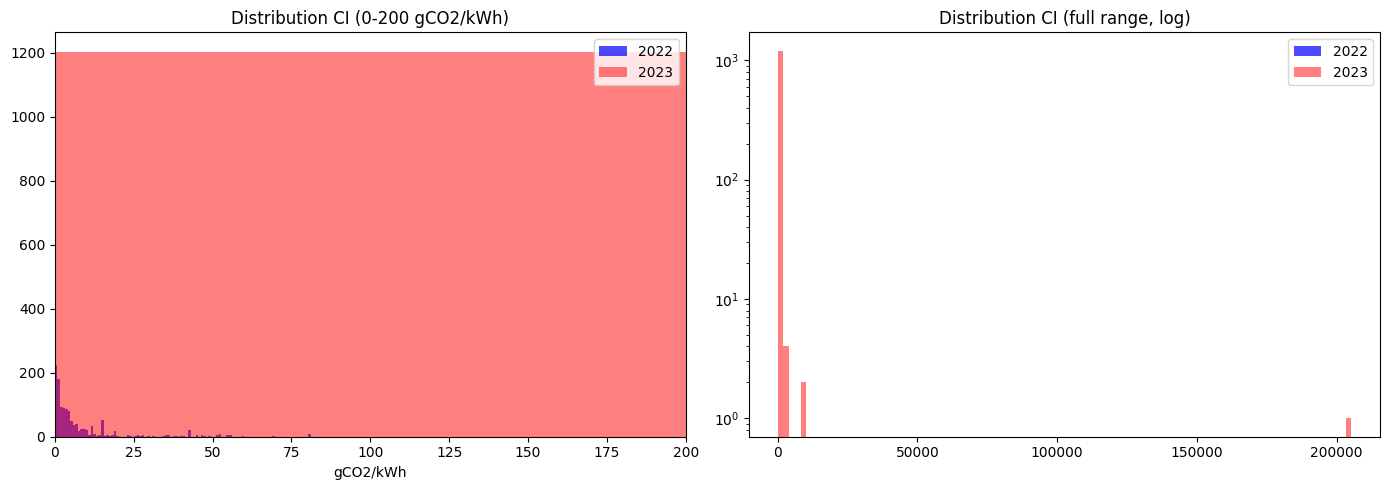

In [19]:
# ── Comparaison complète 2022 vs 2023 ──
import xarray as xr
ds22 = xr.open_dataset(str(OUTPUTS / 'ci_nodal' / 'ci_nodal_2022.nc'))
ci22 = ds22['carbon_intensity'].values  # (8760, 4393) ou (8760, N_filtered)
ci23 = ci_arr.values  # (168, 4393)

print(f"Shape 2022 : {ci22.shape}")
print(f"Shape 2023 : {ci23.shape}")

# Bus IDs
bus22 = [str(b) for b in ds22.coords['bus'].values]
bus23 = [str(b) for b in ci_arr.coords['bus'].values]
print(f"\nBus 2022 : {len(bus22)}")
print(f"Bus 2023 : {len(bus23)}")
print(f"Bus communs : {len(set(bus22) & set(bus23))}")

# Stats sur la même base (1 semaine janvier)
ci22_week = ci22[:168, :]  # première semaine 2022
ci23_week = ci23[:168, :]  # première semaine 2023

# Moyennes par bus (hors zeros)
ci22_mean = np.nanmean(ci22_week, axis=0)
ci23_mean = np.nanmean(ci23_week, axis=0)

# Stats sur bus avec CI > 0
mask22 = ci22_mean > 0
mask23 = ci23_mean > 0

print(f"\n── Stats bus actifs (CI > 0) ──")
print(f"{'':20s} {'2022':>12s} {'2023':>12s}")
print(f"{'Bus actifs':20s} {mask22.sum():>12d} {mask23.sum():>12d}")
print(f"{'CI mean':20s} {ci22_mean[mask22].mean():>12.1f} {ci23_mean[mask23].mean():>12.1f}")
print(f"{'CI median':20s} {np.median(ci22_mean[mask22]):>12.1f} {np.median(ci23_mean[mask23]):>12.1f}")
print(f"{'CI p10':20s} {np.percentile(ci22_mean[mask22], 10):>12.1f} {np.percentile(ci23_mean[mask23], 10):>12.1f}")
print(f"{'CI p90':20s} {np.percentile(ci22_mean[mask22], 90):>12.1f} {np.percentile(ci23_mean[mask23], 90):>12.1f}")
print(f"{'CI max':20s} {ci22_mean[mask22].max():>12.1f} {ci23_mean[mask23].max():>12.1f}")
print(f"{'CI > 100':20s} {(ci22_mean[mask22] > 100).sum():>12d} {(ci23_mean[mask23] > 100).sum():>12d}")
print(f"{'CI > 1000':20s} {(ci22_mean[mask22] > 1000).sum():>12d} {(ci23_mean[mask23] > 1000).sum():>12d}")

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(ci22_mean[mask22], bins=100, color='blue', alpha=0.7, label='2022')
axes[0].hist(ci23_mean[mask23], bins=100, color='red', alpha=0.5, label='2023')
axes[0].set_xlim(0, 200)
axes[0].set_title('Distribution CI (0-200 gCO2/kWh)')
axes[0].set_xlabel('gCO2/kWh'); axes[0].legend()

axes[1].hist(ci22_mean[mask22], bins=100, color='blue', alpha=0.7, label='2022')
axes[1].hist(ci23_mean[mask23], bins=100, color='red', alpha=0.5, label='2023')
axes[1].set_title('Distribution CI (full range, log)')
axes[1].set_yscale('log'); axes[1].legend()

plt.tight_layout(); plt.show()


In [20]:
# ── Post-processing : Log α mixing (comme pipeline_v2) ──
# CI_final = exp(α × log(CI_local) + (1-α) × log(CI_national))
# α=0.1 : 10% signal local, 90% national → lisse les outliers tout en gardant la différenciation spatiale

alpha = 0.1
ci_national_ref = ci_direct.mean()  # 44.5 gCO2/kWh lifecycle
print(f"CI national référence : {ci_national_ref:.1f} gCO2/kWh")
print(f"Alpha : {alpha}")

ci_post = ci_arr.copy()
for i in range(ci_arr.shape[1]):
    ci_local = np.maximum(ci_arr.values[:, i], 1.0)  # floor à 1 pour éviter log(0)
    ci_post.values[:, i] = np.exp(
        alpha * np.log(ci_local) + (1 - alpha) * np.log(ci_national_ref)
    )

# Mettre à 0 les bus sans activité
bus_ids = [str(b) for b in ci_arr.coords['bus'].values]
load_bus_set = set(net.loads.bus.values)
for i, b in enumerate(bus_ids):
    if b not in load_bus_set and ci_arr.values[:, i].mean() == 0:
        ci_post.values[:, i] = 0

print(f"\n── Après post-processing ──")
mask = ci_post.values.mean(axis=0) > 0
ci_active = ci_post.values[:, mask]
print(f"CI mean (bus actifs)  : {ci_active.mean():.1f} gCO2/kWh")
print(f"CI median             : {np.median(ci_active):.1f}")
print(f"CI p10                : {np.percentile(ci_active, 10):.1f}")
print(f"CI p90                : {np.percentile(ci_active, 90):.1f}")
print(f"CI max                : {ci_active.max():.1f}")


CI national référence : 44.5 gCO2/kWh
Alpha : 0.1

── Après post-processing ──
CI mean (bus actifs)  : 40.4 gCO2/kWh
CI median             : 39.5
CI p10                : 34.1
CI p90                : 48.1
CI max                : 172.6


In [21]:
# ── Quel bus a le CI max et pourquoi ? ──
ci_post_mean = ci_post.values.mean(axis=0)
bus_ids = [str(b) for b in ci_arr.coords['bus'].values]

# Top 10 bus CI max
top_idx = np.argsort(ci_post_mean)[::-1][:10]
print("── Top 10 bus CI max (après post-processing) ──")
for rank, idx in enumerate(top_idx):
    bus = bus_ids[idx]
    ci_val = ci_post_mean[idx]
    ci_brut = ci_arr.values[:, idx].mean()
    
    # Quels générateurs sur ce bus ?
    gens_on_bus = net.generators[net.generators.bus == bus]
    carriers = gens_on_bus.groupby('carrier')['p_nom'].sum()
    carrier_str = ', '.join(f'{c}={p:.0f}MW' for c, p in carriers.items()) if len(carriers) > 0 else 'aucun'
    
    # Load sur ce bus ?
    loads_on_bus = net.loads[net.loads.bus == bus]
    load_mw = net.loads_t.p_set[[l for l in loads_on_bus.index]].mean().sum() if len(loads_on_bus) > 0 else 0
    
    # Coordonnées
    lat = net.buses.loc[bus, 'y'] if 'y' in net.buses.columns else '?'
    lon = net.buses.loc[bus, 'x'] if 'x' in net.buses.columns else '?'
    
    print(f"\n  #{rank+1} {bus} — CI post={ci_val:.1f}, CI brut={ci_brut:.1f}")
    print(f"       Coords: ({lat:.2f}, {lon:.2f})")
    print(f"       Gens: {carrier_str}")
    print(f"       Load: {load_mw:.1f} MW")


── Top 10 bus CI max (après post-processing) ──

  #1 way/490176634-225 — CI post=69.9, CI brut=8974.5
       Coords: (47.06, 5.40)
       Gens: biomass=0MW, gas=176MW, solar=11MW, storage=1MW
       Load: 41.7 MW

  #2 relation/17873353-225 — CI post=64.4, CI brut=3081.8
       Coords: (49.37, 1.11)
       Gens: biomass=1MW, gas=132MW, solar=1MW
       Load: 41.1 MW

  #3 way/111414142-400 — CI post=63.3, CI brut=2806.3
       Coords: (43.39, -0.60)
       Gens: biomass=19MW, gas=75MW, solar=58MW
       Load: 41.1 MW

  #4 FR18-225 — CI post=63.2, CI brut=1619.0
       Coords: (49.49, 0.22)
       Gens: biomass=0MW, gas=250MW, oil=92MW, solar=4MW
       Load: 41.1 MW

  #5 way/125550372-225 — CI post=62.6, CI brut=1836.9
       Coords: (48.43, -4.50)
       Gens: biomass=11MW, coal=0MW, gas=116MW, oil=38MW, other=0MW, solar=21MW, storage=7MW, wind=72MW
       Load: 44.1 MW

  #6 way/446406715-400 — CI post=60.9, CI brut=1117.2
       Coords: (48.87, 6.08)
       Gens: biomass=1MW, gas

In [13]:
# ── 6.2 CI nationale load-weighted ──
load_p = net.loads_t.p_set
load_buses = net.loads.bus

total_carbon = 0
total_load = 0
for load_id in load_p.columns:
    bus = load_buses[load_id]
    ci_bus = ci_arr.sel(bus=bus).values
    p_load = load_p[load_id].values
    total_carbon += (ci_bus * p_load).sum()
    total_load += p_load.sum()

ci_national_load = total_carbon / total_load
print(f'CI national (load-weighted) : {ci_national_load:.1f} gCO2/kWh')

# Série temporelle CI nationale
ci_national_ts = pd.Series(0.0, index=net.snapshots)
for t in net.snapshots:
    num = 0
    den = 0
    for load_id in load_p.columns:
        bus = load_buses[load_id]
        ci_val = float(ci_arr.sel(bus=bus, time=t))
        p_val = float(load_p.loc[t, load_id])
        num += ci_val * p_val
        den += p_val
    ci_national_ts[t] = num / den if den > 0 else 0

# Comparaison avec référence RTE
if ci_rte is not None:
    common_idx = ci_national_ts.index.intersection(ci_rte.index)
    m = ci_national_ts[common_idx]
    r = ci_rte[common_idx]
    mape = ((m - r).abs() / r.replace(0, np.nan)).mean() * 100
    bias = (m - r).mean()
    ss_res = ((m - r) ** 2).sum()
    ss_tot = ((r - r.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    print(f'\n── vs CI RTE (direct combustion) ──')
    print(f'MAPE  : {mape:.1f}%')
    print(f'Biais : {bias:+.1f} gCO2/kWh')
    print(f'R²    : {r2:.3f}')

ValueError: operands could not be broadcast together with shapes (168,) (8760,) 

In [ ]:
# ── 6.3 Conservation carbone ──
gen_p = net.generators_t.p_set
gen_carriers = net.generators.carrier
ci_by_gen = gen_carriers.map(ef_map).fillna(300)
C_prod = gen_p.multiply(ci_by_gen, axis=1).sum(axis=1)
P_prod = gen_p.sum(axis=1)

C_load_h = pd.Series(0.0, index=load_p.index)
for load_id in load_p.columns:
    bus = net.loads.loc[load_id, 'bus']
    ci_bus = ci_arr.sel(bus=bus).values
    C_load_h += load_p[load_id].values * ci_bus

ratio = C_load_h.sum() / C_prod.sum()
print(f'C_prod total  : {C_prod.sum()/1e9:.2f} GtCO2·MW')
print(f'C_load total  : {C_load_h.sum()/1e9:.2f} GtCO2·MW')
print(f'Ratio         : {ratio:.3f}')
print(f'Carbon perdu  : {(1-ratio)*100:.1f}%')
print(f'CI prod       : {C_prod.sum()/P_prod.sum():.1f} gCO2/kWh')
print(f'CI load       : {C_load_h.sum()/load_p.sum().sum():.1f} gCO2/kWh')

---
## Étape 7 : Validation

In [ ]:
# ── 7.1 Validation complète ──
import importlib
import carbon_model.validation
import carbon_model.validation.validation
importlib.reload(carbon_model.validation.validation)
from carbon_model.validation.validation import (
    test_energy_conservation,
    test_national_ci_reference,
    test_spatial_sanity,
    aggregate_national_ci,
)

# CI de référence (production directe lifecycle)
reference_ci = ci_direct  # calculé à l'étape 4.5
print(f'CI référence (lifecycle) : {reference_ci.mean():.1f} gCO2/kWh')

# Test 1 : Conservation énergie
r1 = test_energy_conservation(net)
print(f'\n{"✅" if r1.passed else "❌"} {r1.name} : {r1.message}')

# Test 2 : CI nationale vs référence
r2 = test_national_ci_reference(net, ci_nodal_ds, reference_ci)
print(f'{"✅" if r2.passed else "❌"} {r2.name} : {r2.message}')

# Test 3 : Cohérence spatiale
r3 = test_spatial_sanity(net, ci_nodal_ds)
print(f'{"✅" if r3.passed else "❌"} {r3.name} : {r3.message}')

print(f'\n══ Résultat : {sum([r1.passed, r2.passed, r3.passed])}/3 tests réussis ══')

---
## Étape 8 : Sauvegarde (si validation OK)

In [ ]:
# ── 8.1 Sauvegarde CI nodal ──
from carbon_model.tracing.carbon_tracing import save_nodal_ci

out_dir = OUTPUTS / 'ci_nodal'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f'ci_nodal_{YEAR}.nc'

# Décommenter pour sauvegarder
# save_nodal_ci(ci_nodal_ds, out_path)
# print(f'Sauvegardé : {out_path}')
print(f'⚠ Sauvegarde désactivée — décommenter quand validation OK')